# NFL Data Analysis

### Purpose
- This notebook analyzes NFL team and player performance trends to uncover insights on scoring efficiency, player consistency, game attendance, and high-scoring matchups.

### Highlights
1. What are the top 10 teams that have the highest average points per game so far this season?

2. Which teams are most efficient on the road?
    - Which have the most wins and total scored points for away teams?

3. Which players for each of the three game leader positions (QB, RB, WR) appeared most  frequently as game leaders this season?

4. What is the average game attendance by team or venue? 

5. Which games had the highest total combined points each week?
 

## Setup

In [13]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath(".."))
from database.db_utils import get_engine

# Create connection to database
engine = get_engine()

# Visuals setup
sns.set_style('white')

In [9]:
df: pd.DataFrame = pd.read_sql('SELECT * FROM games', engine)
df.head(10)

,game_id,home_team_id,away_team_id,stadium_id,game_type,season_week,date_time,attendance
0,401772510,21,6,3806,regular-season,1,2025-09-05 00:20:00+00:00,69879
1,401772714,24,12,8748,regular-season,1,2025-09-06 00:00:00+00:00,47627
2,401772718,18,22,3493,regular-season,1,2025-09-07 17:00:00+00:00,70006
3,401772719,11,15,3812,regular-season,1,2025-09-07 17:00:00+00:00,64065
4,401772720,17,13,3738,regular-season,1,2025-09-07 17:00:00+00:00,64628
5,401772721,20,23,3839,regular-season,1,2025-09-07 17:00:00+00:00,83253
6,401772722,9,8,3798,regular-season,1,2025-09-07 20:25:00+00:00,77239
7,401772723,14,34,7065,regular-season,1,2025-09-07 20:25:00+00:00,71346
8,401772810,3,16,3933,regular-season,1,2025-09-09 00:15:00+00:00,58742
9,401772827,28,19,3719,regular-season,1,2025-09-07 17:00:00+00:00,64544


## 1. Offense Efficiency
#### What are the top 10 teams that have the highest average points per game so far this season?

### Analysis

In [12]:
# Query for data - selects teams and their avg points scored per week on the season
query = """ 
    SELECT t.team_name, ROUND(AVG(s.points_scored), 2) AS pts_avg
    FROM teams AS t
    JOIN stats AS s 
        ON t.team_id = s.team_id
    GROUP BY t.team_name
    ORDER BY pts_avg DESC
    LIMIT 10;
"""

# Convert data to a dataframe
avg_pts_df: pd.DataFrame = pd.read_sql(query, engine)
avg_pts_df.head(32)


,team_name,pts_avg
0,Indianapolis Colts,33.14
1,Detroit Lions,31.83
2,Dallas Cowboys,31.71
3,Buffalo Bills,27.83
4,Seattle Seahawks,27.67
5,Tampa Bay Buccaneers,27.50
6,Kansas City Chiefs,26.57
7,Green Bay Packers,26.33
8,New England Patriots,25.86
9,Washington Commanders,25.71


### Visuals

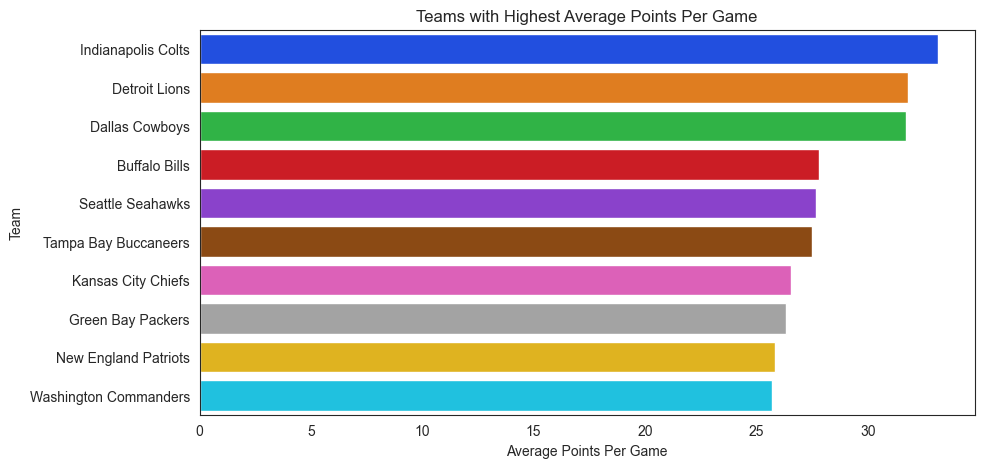

In [35]:
plt.figure(figsize=(10,5))  

# Create horizontal bar chart
sns.barplot(
    data=avg_pts_df,
    y='team_name',
    x='pts_avg',
    hue= 'team_name',
    palette=sns.color_palette('bright'),
    errorbar=None
)
plt.title('Teams with Highest Average Points Per Game')
plt.xlabel('Average Points Per Game')
plt.ylabel('Team')
plt.show()


## 2. Road Game Efficency
#### Which have the most wins and total scored points for away teams?

### Analysis

### Visuals

## 3. Game Leaders
#### Which players for each of the three game leader positions (QB, RB, WR) appeared most frequently as game leaders this season?

### Analysis

### Visuals

## 4. What is the average game attendance by team or venue? 

### Analysis

### Visuals

## 5. Which games had the highest total combined points each week?

### Analysis

### Visuals